# QC of diaPASEF data generated

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from setuptools.command.bdist_egg import make_zipfile

from Old.Data_filtration_and_processing import element
from src.QC import *
from src.plotting_functions import *
from src.filters import *
from src.column_spec import *

In [3]:
df = pd.read_csv("../../Experiment/hme1_diaPASEF/Data/Processed/20260818_peptide_MS2quant_None_transformed_limma_phPlus.tsv", sep="\t", low_memory=False)
df.head(5)

,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,RPS6KA3S375A_log2:FFDR_ALL_omnibus,RPS6KA3S375A_log2:adjustedFFDR_EGF_omnibus,RPS6KA3S375A_log2:adjustedFFDR_ALL_omnibus,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT
0,P16333_147_176_1_1_S166,NCK1,P16333,GSYNGQVGWFPSNYVTEEGDSPLGDHVGSLSEK,KCSDGWWR.GSYNGQVGWFPSNYVTEEGDSPLGDHVGSLSEK.LAA...,146,178,33,1.0,P16333,...,0.999992,0.000004,0.000004,0.380409,True,NaN,NaN,NaN,NaN,NaN
1,Q9Y618_1595_1611_1_0,NCOR2,Q9Y618,EIAKSPHSTVPEHHPHPISPYEHLLR;SPHSTVPEHHPHPISPYEHLLR,RKLTSTPR.EIAKSPHSTVPEHHPHPISPYEHLLR.GVSGVDLY,1591,1616,26,1.0,Q9Y618,...,0.999992,0.000004,0.000004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Q9H2G2_565_571_2_2_S565T569,SLK,Q9H2G2,VDEDSAEDTQSNDGK;VDEDSAEDTQSNDGKEVVEVGQK,EAADVAQK.VDEDSAEDTQSNDGKEVVEVGQK.LINKPMVG,561,583,23,1.0,Q9H2G2,...,NaN,NaN,NaN,0.323995,False|False,NaN,NaN,NaN,NaN,NaN
3,O15085_1452_1469_1_1_S1466,ARHGEF11,O15085,SLGGESSGGTTPVGSFHTEAAR,LAHRELLK.SLGGESSGGTTPVGSFHTEAAR.WTDGSLSP,1452,1473,22,1.0,O15085,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
4,P08670_412_420_1_1_S419,VIM,P08670,ISLPLPNFSSLNLR,LLEGEESR.ISLPLPNFSSLNLR.ETNLDSLP,411,424,14,1.0,P08670,...,NaN,NaN,NaN,0.542262,False,NaN,NaN,NaN,NaN,NaN


In [4]:
CELL_LINES = ["WT", "EGFRT693A", "BRAFS151A1", "SOS1S1178A", "SHOC2T71A", "BRAFS151A2", "GAB1Y259A", "RPS6KA3S375A"] # MIX
CL_SELECTION = ["WT"]
CONDITION = ["_EGF_"]
DATA_TYPE = "raw:abs"

## Missingness

(<Figure size 1350x500 with 1 Axes>,
 <Axes: title={'center': "Missing values per sample - ['WT']"}, xlabel='Sample', ylabel='% missing // zero values'>)

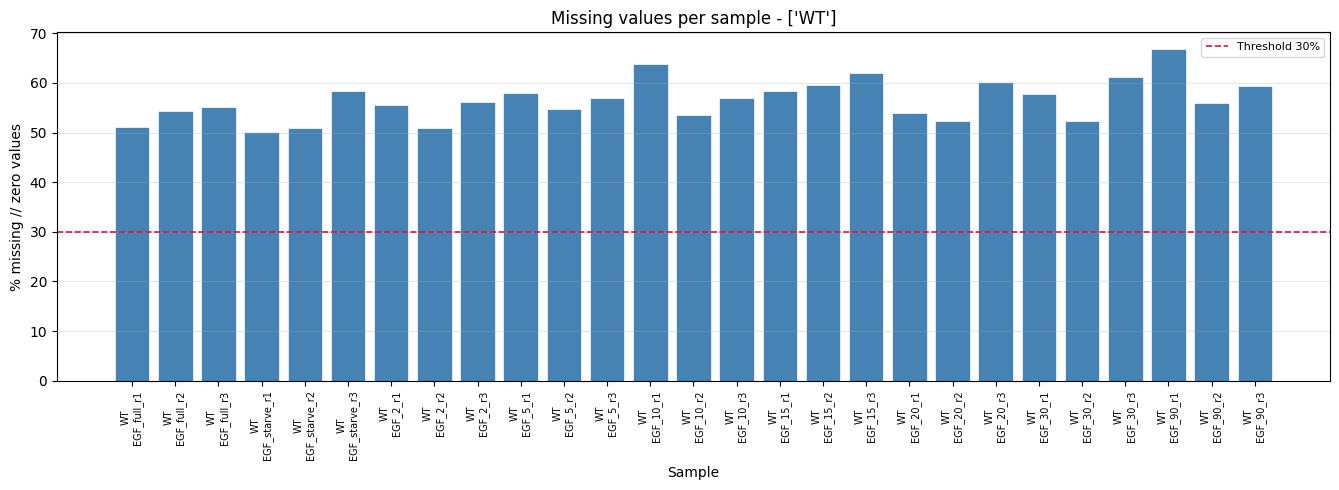

In [5]:
missing_values_per_sample(df,
                         cell_lines=CL_SELECTION,
                         conditions=["_EGF_"],
                         data_type = DATA_TYPE,
                         missing_threshold=0.30,
                         figsize=None,
                         title= f"Missing values per sample - {CL_SELECTION}",
                         ax=None,
)

(<Figure size 1350x500 with 1 Axes>,
 <Axes: title={'center': "Detected peptides per sample - ['WT']"}, xlabel='Sample', ylabel='Number of detected peptides'>)

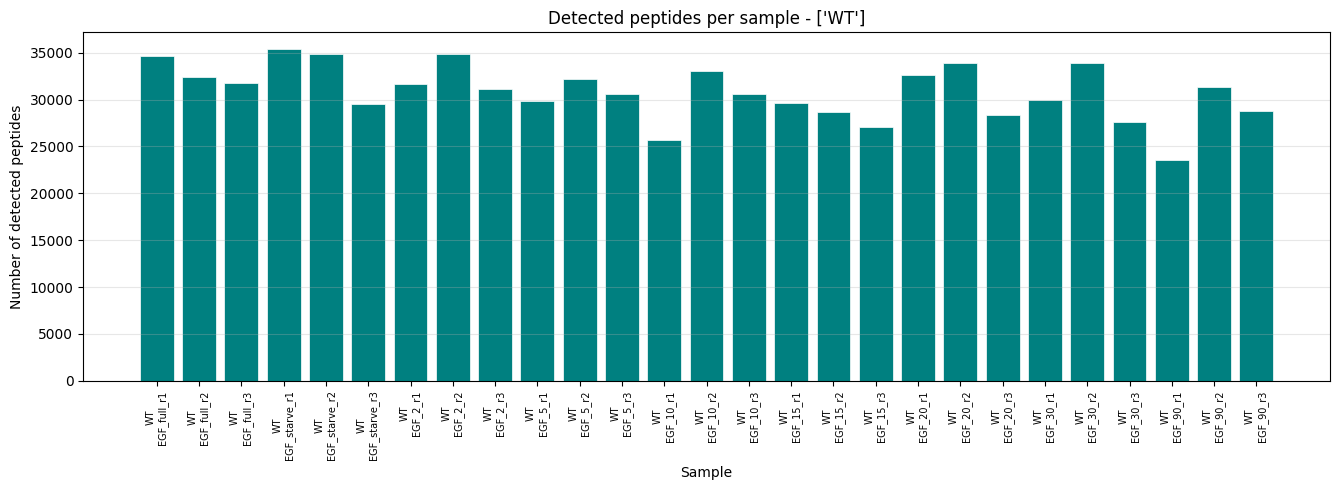

In [6]:
peptide_count_per_sample(df,
                         cell_lines = CL_SELECTION,
                         conditions = CONDITION,
                         data_type = DATA_TYPE,
                         missing_value=0.0,
                         figsize = None,
                         title = f"Detected peptides per sample - {CL_SELECTION}",
                         ax = None,
)

## Replicate coverage / counts

How many sites are actually usable for a time course? A site is only usable if it was measured
at **every** timepoint — but the replicate that saw it does not have to be the same one each time.
A site detected in (r1, r3) at 2 min and in (r2, r3) at 5 min is covered by 2 replicates at both
timepoints, so its **coverage depth** over that time course is 2.

Depth is therefore the *minimum* per-timepoint replicate count over the timepoints of a sample group,
and the depth of a **combination** of cell lines is the minimum over all of them: a site is only
usable for a comparison if every cell line in that comparison measured it at every timepoint.
Combining cell lines can only lower the depth, never raise it.

Sites are keyed on the first of `site`, `site_index`, `peptide_index`, `Index` present in the table
(so `site`, built in the cell above), or on `df.index` if none of them exist. Pass `site_col=` to
`replicate_coverage_matrix` to choose a different one.

| function (`src/QC.py`) | what it answers |
|---|---|
| `replicate_coverage_matrix` | replicates per site per cell line × condition × timepoint (raw material) |
| `replicate_coverage_depth` | depth per site per cell line, or per combination of cell lines |
| `coverage_summary` | how many sites reach ≥1, ≥2, ≥3 replicates |
| `plot_replicate_coverage` | the same as a grouped bar chart |
| `coverage_per_timepoint` / `plot_coverage_per_timepoint` | *which* timepoint is the bottleneck |
| `sites_with_coverage` | the site keys themselves |
| `filter_by_coverage` | the DataFrame subset to those sites |

In [7]:
# Replicates per site, per cell line x condition x timepoint. This is the raw material for everything below — nothing has been reduced yet.
# Sites are keyed on the "Index" column; cell lines / conditions / timepoints are auto-detected from the column names when left as None. Use exclude_full / exclude_starve / timepoints=[...] to leave the controls (or any run) out of the minimum.
coverage_matrix = replicate_coverage_matrix(df,
                                            cell_lines=None,
                                            conditions=CONDITION,
                                            data_type=DATA_TYPE,
                                            timepoints=None,
                                            exclude_full=False,
                                            exclude_starve=False,
                                            missing_value=0.0,
                                            site_col= "site")
print(coverage_matrix.shape)
coverage_matrix.head()

(71087, 73)


cell_line                                            WT                        \
condition                                           EGF                         
timepoint                                          full starve  2  5 10 15 20   
site                                                                            
P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDsPL...    2      3  3  3  3  3  0   
Q9Y618_1595_1611_1_0~EIAKSPHsTVPEHHPHPISPYEHLLR       2      3  1  2  1  0  2   
Q9H2G2_565_571_2_2_S565T569~VDEDsAEDtQSNDGKEVVE...    2      1  2  0  1  1  0   
O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGsFHTEAAR     0      0  1  0  1  0  1   
P08670_412_420_1_1_S419~ISLPLPNFsSLNLR                2      2  3  2  3  2  3   

cell_line                                                EGFRT693A  ...  \
condition                                                      EGF  ...   
timepoint                                          30 90      full  ...   
site                                                                ...   
P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDsPL...  2  2         3  ...   
Q9Y618_1595_1611_1_0~EIAKSPHsTVPEHHPHPISPYEHLLR     1  1         2  ...   
Q9H2G2_565_571_2_2_S565T569~VDEDsAEDtQSNDGKEVVE...  1  1         1  ...   
O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGsFHTEAAR   0  1         0  ...   
P08670_412_420_1_1_S419~ISLPLPNFsSLNLR              3  0         2  ...   

cell_line                                          RPS6KA3S375A               \
condition                                                   EGF                
timepoint                                                  full starve  2  5   
site                                                                           
P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDsPL...            2      2  2  1   
Q9Y618_1595_1611_1_0~EIAKSPHsTVPEHHPHPISPYEHLLR               2      2  3  2   
Q9H2G2_565_571_2_2_S565T569~VDEDsAEDtQSNDGKEVVE...            1      1  0  1   
O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGsFHTEAAR             2      2  2  0   
P08670_412_420_1_1_S419~ISLPLPNFsSLNLR                        1      3  1  2   

cell_line                                                            MIX  
condition                                                            EGF  
timepoint                                          10 15 20 30 90 starve  
site                                                                      
P16333_147_176_1_1_S166~GSYNGQVGWFPSNYVTEEGDsPL...  2  3  2  2  1      3  
Q9Y618_1595_1611_1_0~EIAKSPHsTVPEHHPHPISPYEHLLR     2  1  2  2  3      2  
Q9H2G2_565_571_2_2_S565T569~VDEDsAEDtQSNDGKEVVE...  1  1  2  1  1      2  
O15085_1452_1469_1_1_S1466~SLGGESSGGTTPVGsFHTEAAR   1  1  1  0  1      1  
P08670_412_420_1_1_S419~ISLPLPNFsSLNLR              0  2  2  2  2      3  

[5 rows x 73 columns]

### Check number of counts of a site per cell_line and within groups

Replicate coverage per timepoint (71087 sites total):
  WT                   ≥1 rep : 23175 (32.6%) | ≥2 reps: 10700 (15.1%) | ≥3 reps: 4972 (7.0%)
  EGFRT693A            ≥1 rep : 22873 (32.2%) | ≥2 reps: 10480 (14.7%) | ≥3 reps: 4937 (6.9%)
  BRAFS151A1           ≥1 rep : 23317 (32.8%) | ≥2 reps: 10555 (14.8%) | ≥3 reps: 4261 (6.0%)
  SOS1S1178A           ≥1 rep : 24158 (34.0%) | ≥2 reps: 11099 (15.6%) | ≥3 reps: 4332 (6.1%)
  SHOC2T71A            ≥1 rep : 23555 (33.1%) | ≥2 reps: 10597 (14.9%) | ≥3 reps: 361 (0.5%)
  BRAFS151A2           ≥1 rep : 24676 (34.7%) | ≥2 reps: 11738 (16.5%) | ≥3 reps: 5485 (7.7%)
  GAB1Y259A            ≥1 rep : 25092 (35.3%) | ≥2 reps: 11840 (16.7%) | ≥3 reps: 5503 (7.7%)
  RPS6KA3S375A         ≥1 rep : 23348 (32.8%) | ≥2 reps: 10662 (15.0%) | ≥3 reps: 5127 (7.2%)
  MIX                  ≥1 rep : 49137 (69.1%) | ≥2 reps: 32092 (45.1%) | ≥3 reps: 16954 (23.8%)
  ALL                  ≥1 rep : 11372 (16.0%) | ≥2 reps: 5783 (8.1%) | ≥3 reps: 243 (0.3%)


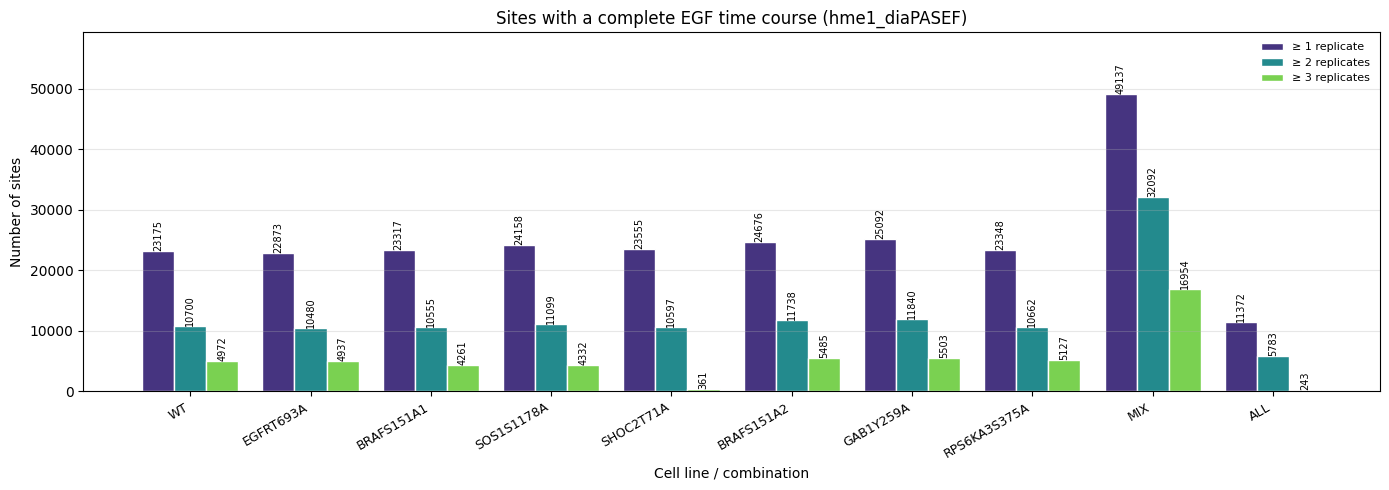

In [8]:
GROUPS = {}

# One column per cell line, plus an "ALL" group: sites with a complete time course in every cell line at the same time.
depth = replicate_coverage_depth(counts = coverage_matrix,
                                 groups = None,
                                 include_all=True,) # Returns the coverage per site per cell line.

# For grouping here, you have to define and calculate the groups for the replicate_coverage_depth()
coverage_table = coverage_summary(depth = depth,
                                  max_depth= None,
                                  print_summary = True,)
coverage_df, coverage_fig, ax = plot_replicate_coverage(depth = depth,
                                       max_depth = None,
                                       as_percent= False,
                                       title="Sites with a complete EGF time course (hme1_diaPASEF)",)


### What is the coverage across time points?

These are the number of phospho-peptides that have "n" coverage at each time point. DO NOT GET CONFUSED: phosphopeptides can 3 replicates at several time points and still have missingness in other time points, this is why here the counts of phosphopeptides with 3 replicates per time point is higher than for the graph above.

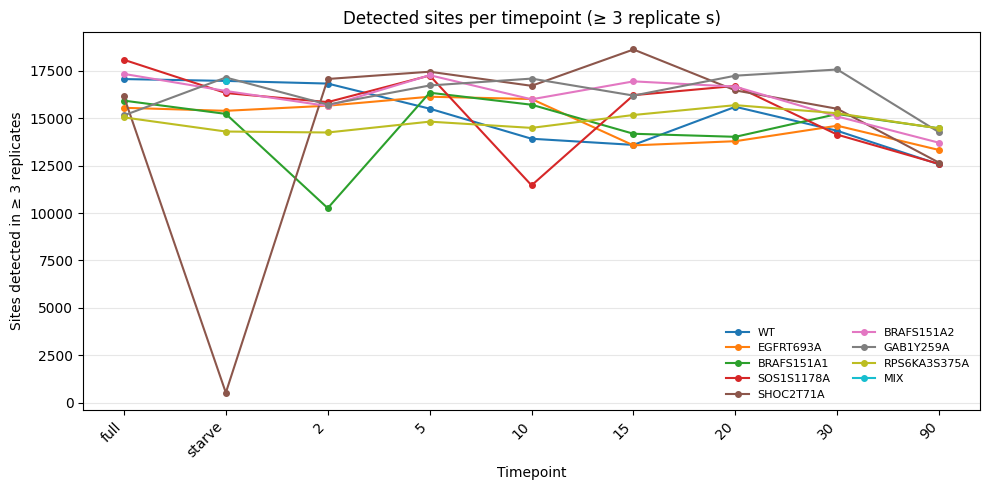

In [9]:
cpt_df = coverage_per_timepoint(counts = coverage_matrix,
                           max_depth = 3,
                           print_summary = False,)
table, fig, ax = plot_coverage_per_timepoint(counts= coverage_matrix,
                                min_reps=3,
                                title=None,)

## Filtering based on coverage

`sites_with_coverage` returns the site keys, so any of the groups above can be turned into a row
filter for the rest of the preprocessing (fold changes, clustering, mutant comparison).

In [11]:
group = "EGFRT693A"
WT_f_df = filter_by_coverage(df = df,
                                depth = depth,
                                group=group,
                                min_reps=2,)
print(f"key column: {depth.index.name}")
print(f"{len(WT_f_df)} of {len(df)} sites covered in >= 2 replicates at every timepoint in {group}")
WT_f_df

key column: site
10480 of 71087 sites covered in >= 2 replicates at every timepoint in EGFRT693A


,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,RPS6KA3S375A_log2:FFDR_ALL_omnibus,RPS6KA3S375A_log2:adjustedFFDR_EGF_omnibus,RPS6KA3S375A_log2:adjustedFFDR_ALL_omnibus,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT
9,P0DMV8_362_371_1_1_S362,HSPA1A,P0DMV8,DLNKSINPDEAVAYGAAVQAAILMGDK,LQDFFNGR.DLNKSINPDEAVAYGAAVQAAILMGDK.SENVQDLL,358,384,27,1.0000,P0DMV8,...,0.999992,0.000004,0.000004,0.452000,False,NaN,NaN,NaN,NaN,NaN
12,Q96RK0_2306_2318_1_1_S2318,CIC,Q96RK0,NSTDLDSAPEDPTSPKR;RKNSTDLDSAPEDPTSPK;KNSTDLDSA...,GSYRKKRK.NSTDLDSAPEDPTSPK.RKMRRRSS,2305,2320,16,1.0000,Q96RK0,...,0.002286,2.641009,2.641009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,P35269_385_400_1_1_T389,GTF2F1,P35269,GNSRPGTPSAEGGSTSSTLR,KPSGGSSR.GNSRPGTPSAEGGSTSSTLR.AAASKLEQ,383,402,20,1.0000,P35269,...,0.999992,0.000004,0.000004,0.772932,True,human,"activity, inhibited","transcription, inhibited",NaN,NaN
26,Q71RC2_717_722_1_1_S722,LARP4,Q71RC2,EQYVPPRSPK;NGKEQYVPPRSPK,GVTRRNGK.EQYVPPRSPK.-,715,724,10,1.0000,Q71RC2,...,0.999992,0.000004,0.000004,0.690329,True,NaN,NaN,NaN,NaN,NaN
32,Q9HD20_899_905_1_1_S899,ATP13A1,Q9HD20,DSPTLSNSGIR;RPRDSPTLSNSGIR,VERRRRPR.DSPTLSNSGIR.ATSRTAKQ,898,908,11,1.0000,Q9HD20,...,0.999992,0.000004,0.000004,0.405902,True,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71051,O00429_607_616_1_1_S616,DNM1L,O00429,SKPIPIMPASPQKGHAVNLLDVPVPVAR;SKPIPIMPASPQK,EELLAEEK.SKPIPIMPASPQK.GHAVNLLD,607,619,13,1.0000,O00429,...,0.999992,0.000004,0.000004,0.714774,True,human,"activity, induced; molecular association, regu...","cell differentiation, inhibited; carcinogenesi...",MFF(INDUCES); DRP1(INDUCES); Rab7(INDUCES),NaN
71055,P15336_253_272_1_0,ATF2,P15336,PVTMVPSVPGIPGPSSPQPVQSEAK,PAAVPLVR.PVTMVPSVPGIPGPSSPQPVQSEAK.MRLKAALT,251,275,25,1.0000,P15336,...,0.999992,0.000004,0.000004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71068,Q9HCK8_1993_2023_2_2_S1995S2008,CHD8,Q9HCK8,TASPLPLRPDAPVEKSPEETATQVPSLESLTLK,LHQQYTSR.TASPLPLRPDAPVEKSPEETATQVPSLESLTLK.LEH...,1993,2025,33,1.0000,Q9HCK8,...,0.999992,0.000004,0.000004,0.431316,True|True,NaN,NaN,NaN,NaN,NaN
71082,Q13112_507_538_1_1_S538,CHAF1B,Q13112,TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELKR;TDTPPSS...,RINLTPLK.TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELK...,507,543,37,1.0000,Q13112,...,0.999992,0.000004,0.000004,0.538663,True,NaN,NaN,NaN,NaN,NaN


### For how many of the sites a time point has been detected in at least 2 sites (the starve and another one)

In [12]:
for cell in CELL_LINES:
    fc_cols = ColumnSpec.select(df = df,
                                cell_lines = [cell],
                                data_type = "log2:FC",
                                conditions=["_EGF_"])
    n_any = int(df[fc_cols].notna().any(axis=1).sum()) # columns for which there is no time point with FC bigger than fc_filter
    n_all = int(df[fc_cols].notna().all(axis=1).sum()) # columns with at least one time point with FC bigger than fc_filter
    print(f"{cell:<14} FC at >=1 timepoint: {n_any:>6} | at every timepoint: {n_all:>6} | of {len(df)}")


WT             FC at >=1 timepoint:  50250 | at every timepoint:  23175 | of 71087
EGFRT693A      FC at >=1 timepoint:  48291 | at every timepoint:  22873 | of 71087
BRAFS151A1     FC at >=1 timepoint:  49241 | at every timepoint:  23317 | of 71087
SOS1S1178A     FC at >=1 timepoint:  48541 | at every timepoint:  24158 | of 71087
SHOC2T71A      FC at >=1 timepoint:  43467 | at every timepoint:  23555 | of 71087
BRAFS151A2     FC at >=1 timepoint:  48828 | at every timepoint:  24676 | of 71087
GAB1Y259A      FC at >=1 timepoint:  50564 | at every timepoint:  25092 | of 71087
RPS6KA3S375A   FC at >=1 timepoint:  47415 | at every timepoint:  23348 | of 71087


## Missingness

(<Figure size 1350x1000 with 1 Axes>,
 <Axes: title={'center': 'Replicate detection map'}, ylabel='71087 sites'>)

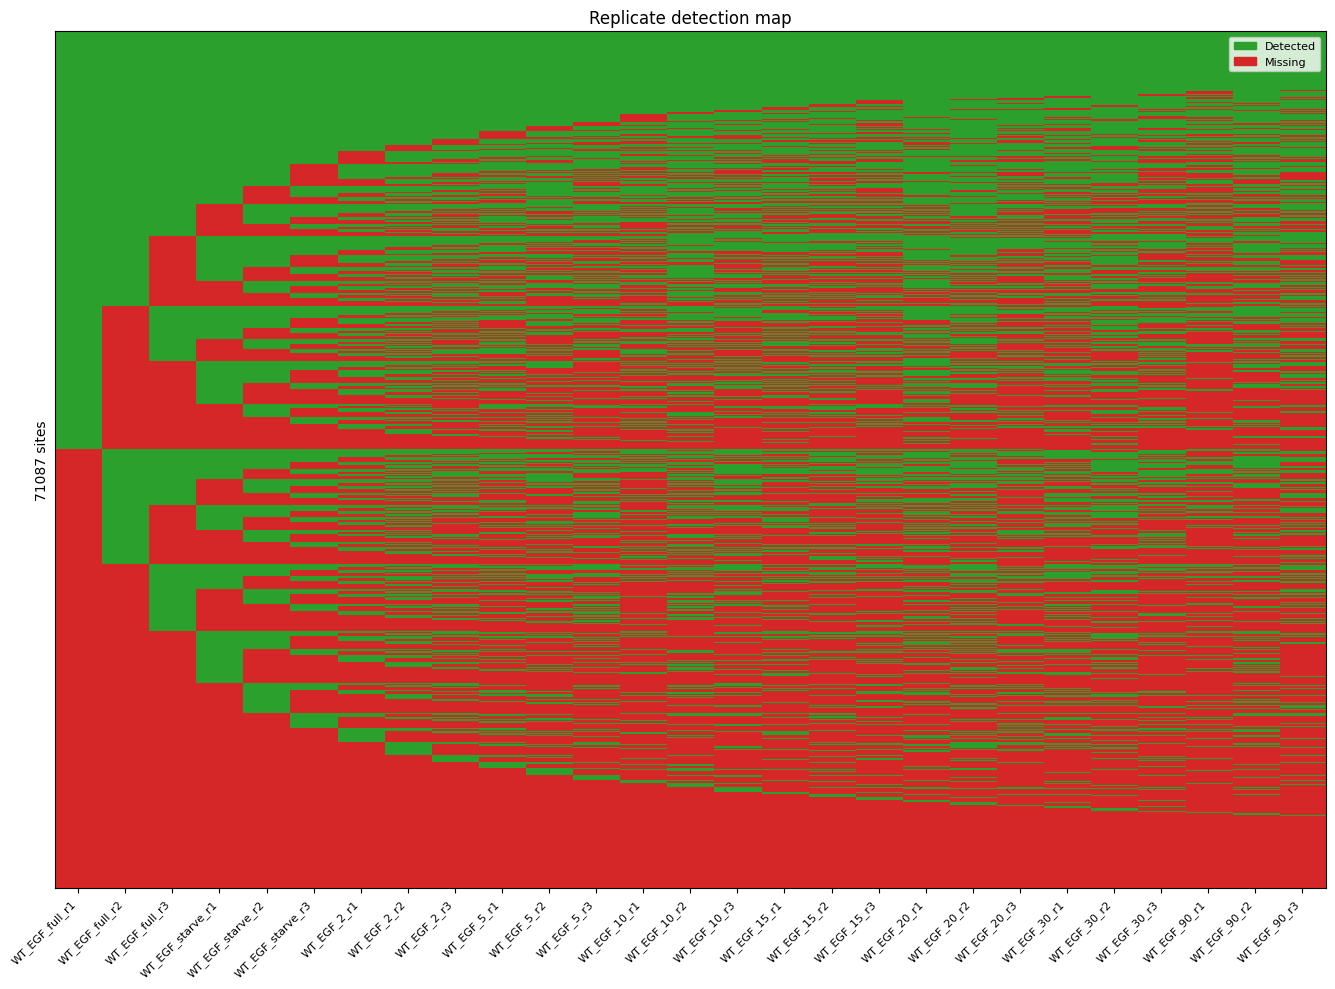

In [18]:
replicate_detection_map(
    df,
    cell_lines=["WT"], #, "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], #, "_INS_","_EGFnINS_"],
    data_type="raw:abs",
    missing_value=0.0,
    figsize=None,
    title="Replicate detection map",
    ax=None,
)

## Localization completenes


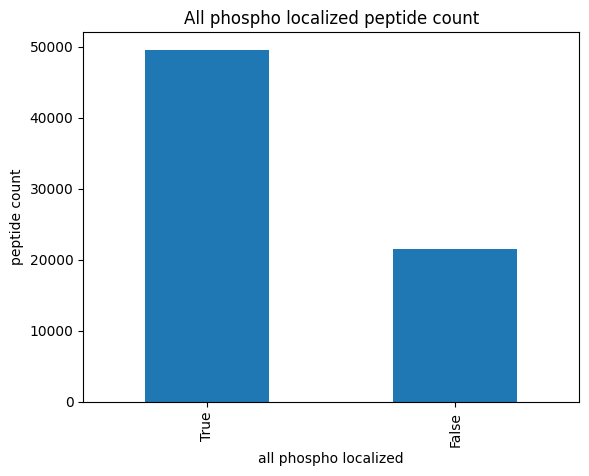

In [42]:
df['total_phospho'] = df["peptide_index"].str.split("_").str[3]
df["localized_phospho"] = df["peptide_index"].str.split("_").str[4]
df['all_phospho_localized'] = df['total_phospho'] == df["localized_phospho"]

df['all_phospho_localized'].value_counts().plot(kind='bar')
plt.xlabel('all phospho localized')
plt.ylabel('peptide count')
plt.title('All phospho localized peptide count')
plt.show()

## Intensity distribution

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Intensity distribution per sample'}, xlabel='log2 intensity', ylabel='Density'>)

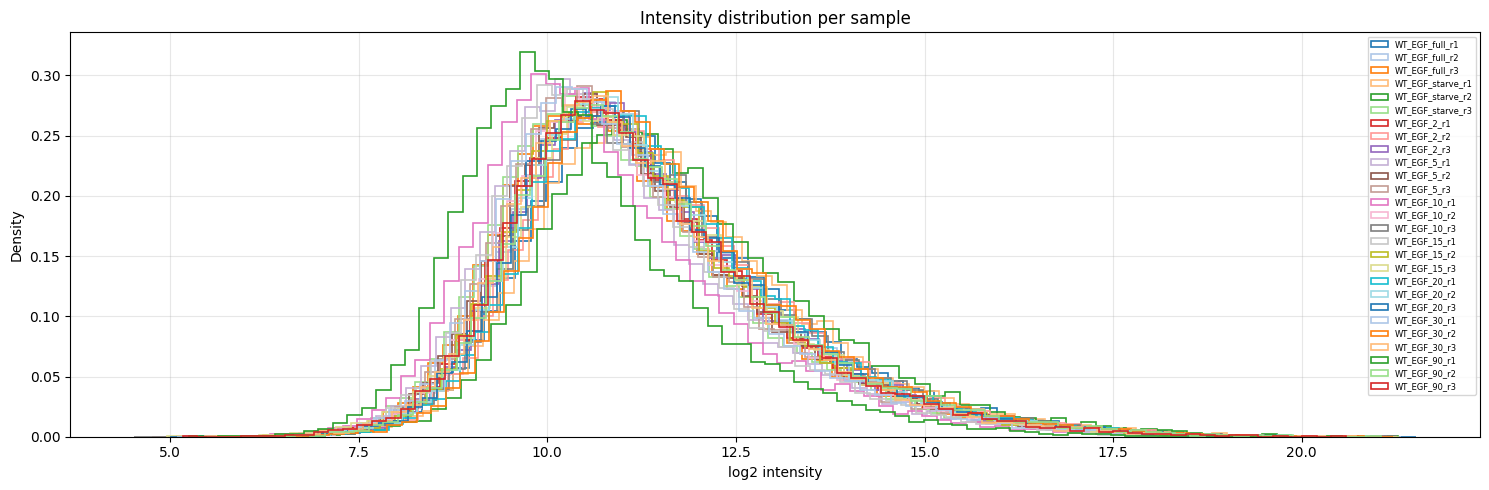

In [51]:
intensity_distribution(df,
                       cell_lines=CL_SELECTION,
                       conditions=["_EGF_"],
                       data_type="log2:abs",
                       log_transform= False,
                       figsize=(15,5),
                       title="Intensity distribution per sample",
                       ax=None,
)

## CV variance

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/src/QC.py:1348: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'CV distribution per timepoint'}, xlabel='Condition / timepoint', ylabel='CV (%)'>)

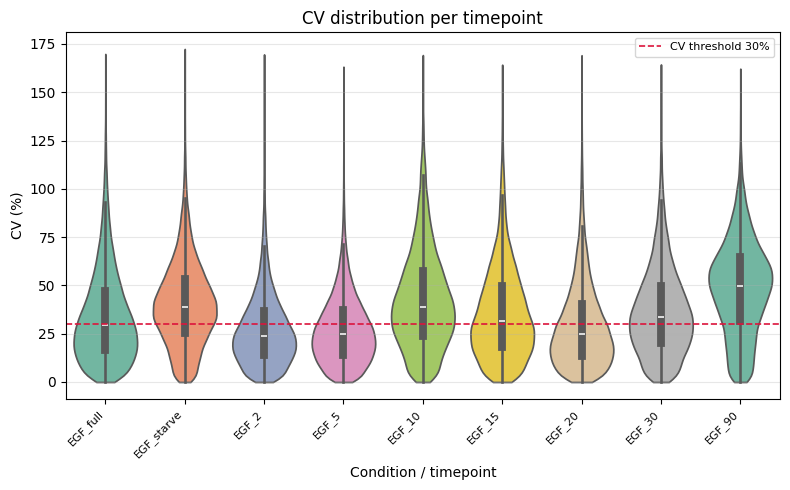

In [50]:
cv_distribution(df,
                cell_lines=CL_SELECTION,
                conditions=["_EGF_"],
                data_type="raw:cv",
                cv_threshold=30.0,
                figsize=None,
                title="CV distribution per timepoint",
                ax=None,
)

## PCA

### Filter based on cell line and depth

In [69]:
group = "WT"
WT_f_df = filter_by_coverage(df = df,
                                depth = depth,
                                group=group,
                                min_reps=2,)
print(f"key column: {depth.index.name}")
print(f"{len(WT_f_df)} of {len(df)} sites covered in >= 2 replicates at every timepoint in {group}")
WT_f_df

key column: site
10700 of 71087 sites covered in >= 2 replicates at every timepoint in WT


,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT,total_phospho,localized_phospho,all_phospho_localized
9,P0DMV8_362_371_1_1_S362,HSPA1A,P0DMV8,DLNKSINPDEAVAYGAAVQAAILMGDK,LQDFFNGR.DLNKSINPDEAVAYGAAVQAAILMGDK.SENVQDLL,358,384,27,1.0000,P0DMV8,...,0.452000,False,NaN,NaN,NaN,NaN,NaN,1,1,True
12,Q96RK0_2306_2318_1_1_S2318,CIC,Q96RK0,NSTDLDSAPEDPTSPKR;RKNSTDLDSAPEDPTSPK;KNSTDLDSA...,GSYRKKRK.NSTDLDSAPEDPTSPK.RKMRRRSS,2305,2320,16,1.0000,Q96RK0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,True
24,P35269_385_400_1_1_T389,GTF2F1,P35269,GNSRPGTPSAEGGSTSSTLR,KPSGGSSR.GNSRPGTPSAEGGSTSSTLR.AAASKLEQ,383,402,20,1.0000,P35269,...,0.772932,True,human,"activity, inhibited","transcription, inhibited",NaN,NaN,1,1,True
26,Q71RC2_717_722_1_1_S722,LARP4,Q71RC2,EQYVPPRSPK;NGKEQYVPPRSPK,GVTRRNGK.EQYVPPRSPK.-,715,724,10,1.0000,Q71RC2,...,0.690329,True,NaN,NaN,NaN,NaN,NaN,1,1,True
32,Q9HD20_899_905_1_1_S899,ATP13A1,Q9HD20,DSPTLSNSGIR;RPRDSPTLSNSGIR,VERRRRPR.DSPTLSNSGIR.ATSRTAKQ,898,908,11,1.0000,Q9HD20,...,0.405902,True,NaN,NaN,NaN,NaN,NaN,1,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71055,P15336_253_272_1_0,ATF2,P15336,PVTMVPSVPGIPGPSSPQPVQSEAK,PAAVPLVR.PVTMVPSVPGIPGPSSPQPVQSEAK.MRLKAALT,251,275,25,1.0000,P15336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,False
71068,Q9HCK8_1993_2023_2_2_S1995S2008,CHD8,Q9HCK8,TASPLPLRPDAPVEKSPEETATQVPSLESLTLK,LHQQYTSR.TASPLPLRPDAPVEKSPEETATQVPSLESLTLK.LEH...,1993,2025,33,1.0000,Q9HCK8,...,0.431316,True|True,NaN,NaN,NaN,NaN,NaN,2,2,True
71070,P35568_1000_1012_1_1_S1005,IRS1,P35568,QSYVDTSPAAPVSYADMR,TMQMSCPR.QSYVDTSPAAPVSYADMR.TGIAAEEV,999,1016,18,1.0000,P35568,...,0.284332,True,NaN,NaN,NaN,NaN,NaN,1,1,True
71082,Q13112_507_538_1_1_S538,CHAF1B,Q13112,TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELKR;TDTPPSS...,RINLTPLK.TDTPPSSVPTSVISTPSTEEIQSETPGDAQGSPPELK...,507,543,37,1.0000,Q13112,...,0.538663,True,NaN,NaN,NaN,NaN,NaN,1,1,True


#### Filter based on representatice proteins of the pathway

In [81]:
signor = pd.read_csv("../../External_Data/Metadata/Signor/SIGNOR-EGF_14_08_26.tsv", sep="\t", low_memory=False)

signor_proteins = set(signor["IDA"].to_list() + signor["IDB"].to_list()) # ENTITYA  ENTITYB
signor_proteins = [element for element in signor_proteins if "SIGNOR" not in element and "CHEBI" not in element]
len(signor_proteins)

25

In [95]:
sub_df = WT_f_df.loc[WT_f_df["protein_Id"].isin(signor_proteins)].copy()

# log2_cols = ColumnSpec.select(df = sub_df,
#                               data_type = "log2:abs",
#                               conditions=["_EGF_"],
#                               cell_lines=["WT"],)
#
# sub_df = sub_df[["site"]+log2_cols]
sub_df

,peptide_index,protein_name,protein_Id,peptide_seq,SequenceWindow,Start,End,Peptide Length,Probability,Protein,...,functional_score,ERK_motif,ORGANISM,ON_FUNCTION,ON_PROCESS,ON_PROT_INTERACT,ON_OTHER_INTERACT,total_phospho,localized_phospho,all_phospho_localized
441,P29353_139_145_1_1_S139,SHC1,P29353,HGSFVNKPTR,LGGEEWTR.HGSFVNKPTR.GWLHPNDK,137,146,10,1.0000,P29353,...,0.593201,False,human,NaN,"apoptosis, induced",NaN,NaN,1,1,True
1781,P00533_1162_1172_1_1_S1166,EGFR,P00533,GSHQISLDNPDYQQDFFPK,SPAHWAQK.GSHQISLDNPDYQQDFFPK.EAKPNGIF,1161,1179,19,1.0000,P00533,...,0.586968,False,NaN,NaN,NaN,NaN,NaN,1,1,True
2211,Q9UJM3_302_311_1_1_S302,ERRFI1,Q9UJM3,RWSAEVTSSTYSDEDRPPK;WSAEVTSSTYSDEDRPPK,RPVKPDYR.RWSAEVTSSTYSDEDRPPK.VPPREPLS,300,318,19,1.0000,Q9UJM3,...,0.434548,False,NaN,NaN,NaN,NaN,NaN,1,1,True
2625,P12931_69_75_1_1_S75,SRC,P12931,LFGGFNSSDTVTSPQR,APAAAEPK.LFGGFNSSDTVTSPQR.AGPLAGGV,63,78,16,1.0000,P12931,...,0.977503,True,human,protein degradation; ubiquitination; enzymatic...,"cytoskeletal reorganization; cell growth, altered",NaN,NaN,1,1,True
3090,P15056_363_373_1_1_S365,BRAF,P15056,SSSAPNVHINTIEPVNIDDLIR;DRSSSAPNVHINTIEPVNIDDLIR,NQFGQRDR.SSSAPNVHINTIEPVNIDDLIR.DQGFRGDG,363,384,22,1.0000,P15056,...,0.960080,False,human,"molecular association, regulation; enzymatic a...","transcription, induced; cell growth, altered",14-3-3 beta(INDUCES),NaN,1,1,True
3226,Q13153_219_236_1_1_T230,PAK1,Q13153,DVATSPISPTENNTTPPDALTR,PLPVTPTR.DVATSPISPTENNTTPPDALTR.NTEKQKKK,216,237,22,1.0000,Q13153,...,0.708970,True,NaN,NaN,NaN,NaN,NaN,1,1,True
7754,P45985_5_36_1_1_S26,MAP2K4,P45985,AAPSPSGGGGSGGGSGSGTPGPVGSPAPGHPAVSSMQGK,M.AAPSPSGGGGSGGGSGSGTPGPVGSPAPGHPAVSSMQGK.RKAL...,2,40,39,1.0000,P45985,...,0.377195,True,NaN,NaN,NaN,NaN,NaN,1,1,True
8476,Q13233_292_304_1_1_S292,MAP3K1,Q13233,RAPSPDGFSPYSPEETNR,SGRITPPR.RAPSPDGFSPYSPEETNR.RVNKVMRA,289,306,18,1.0000,Q13233,...,0.512463,True,NaN,NaN,NaN,NaN,NaN,1,1,True
10149,P16333_85_96_1_1_S85,NCK1,P16333,RKPSVPDSASPADDSFVDPGER;KPSVPDSASPADDSFVDPGER,TLGIGKVK.RKPSVPDSASPADDSFVDPGER.LYDLNMPA,82,103,22,1.0000,P16333,...,0.717351,False,NaN,NaN,NaN,NaN,NaN,1,1,True
10169,P16333_85_96_1_1_S96,NCK1,P16333,RKPSVPDSASPADDSFVDPGER;KPSVPDSASPADDSFVDPGER,TLGIGKVK.RKPSVPDSASPADDSFVDPGER.LYDLNMPA,82,103,22,1.0000,P16333,...,0.364400,False,NaN,NaN,NaN,NaN,NaN,1,1,True


In [96]:
fig_scatter, fig_variance, pca_df = pca_plot_interactive(
                                                        sub_df,
                                                        cell_lines= ["WT"],
                                                        conditions=["_EGF_"],
                                                        data_type="log2:abs",
                                                        n_components=5,
                                                        impute=True,
                                                        impute_method="mean",
                                                        color_by="condition", #condition  cell_line
                                                        figsize=(700, 600), #(1000, 800)
                                                        title="PCA of replicate samples - WT",
                                                    )
fig_scatter.show()

## Plotting temporal profiles

Ploting sites of protein EGFR
EGFR_P00533_log2:FC_ — plot not saved


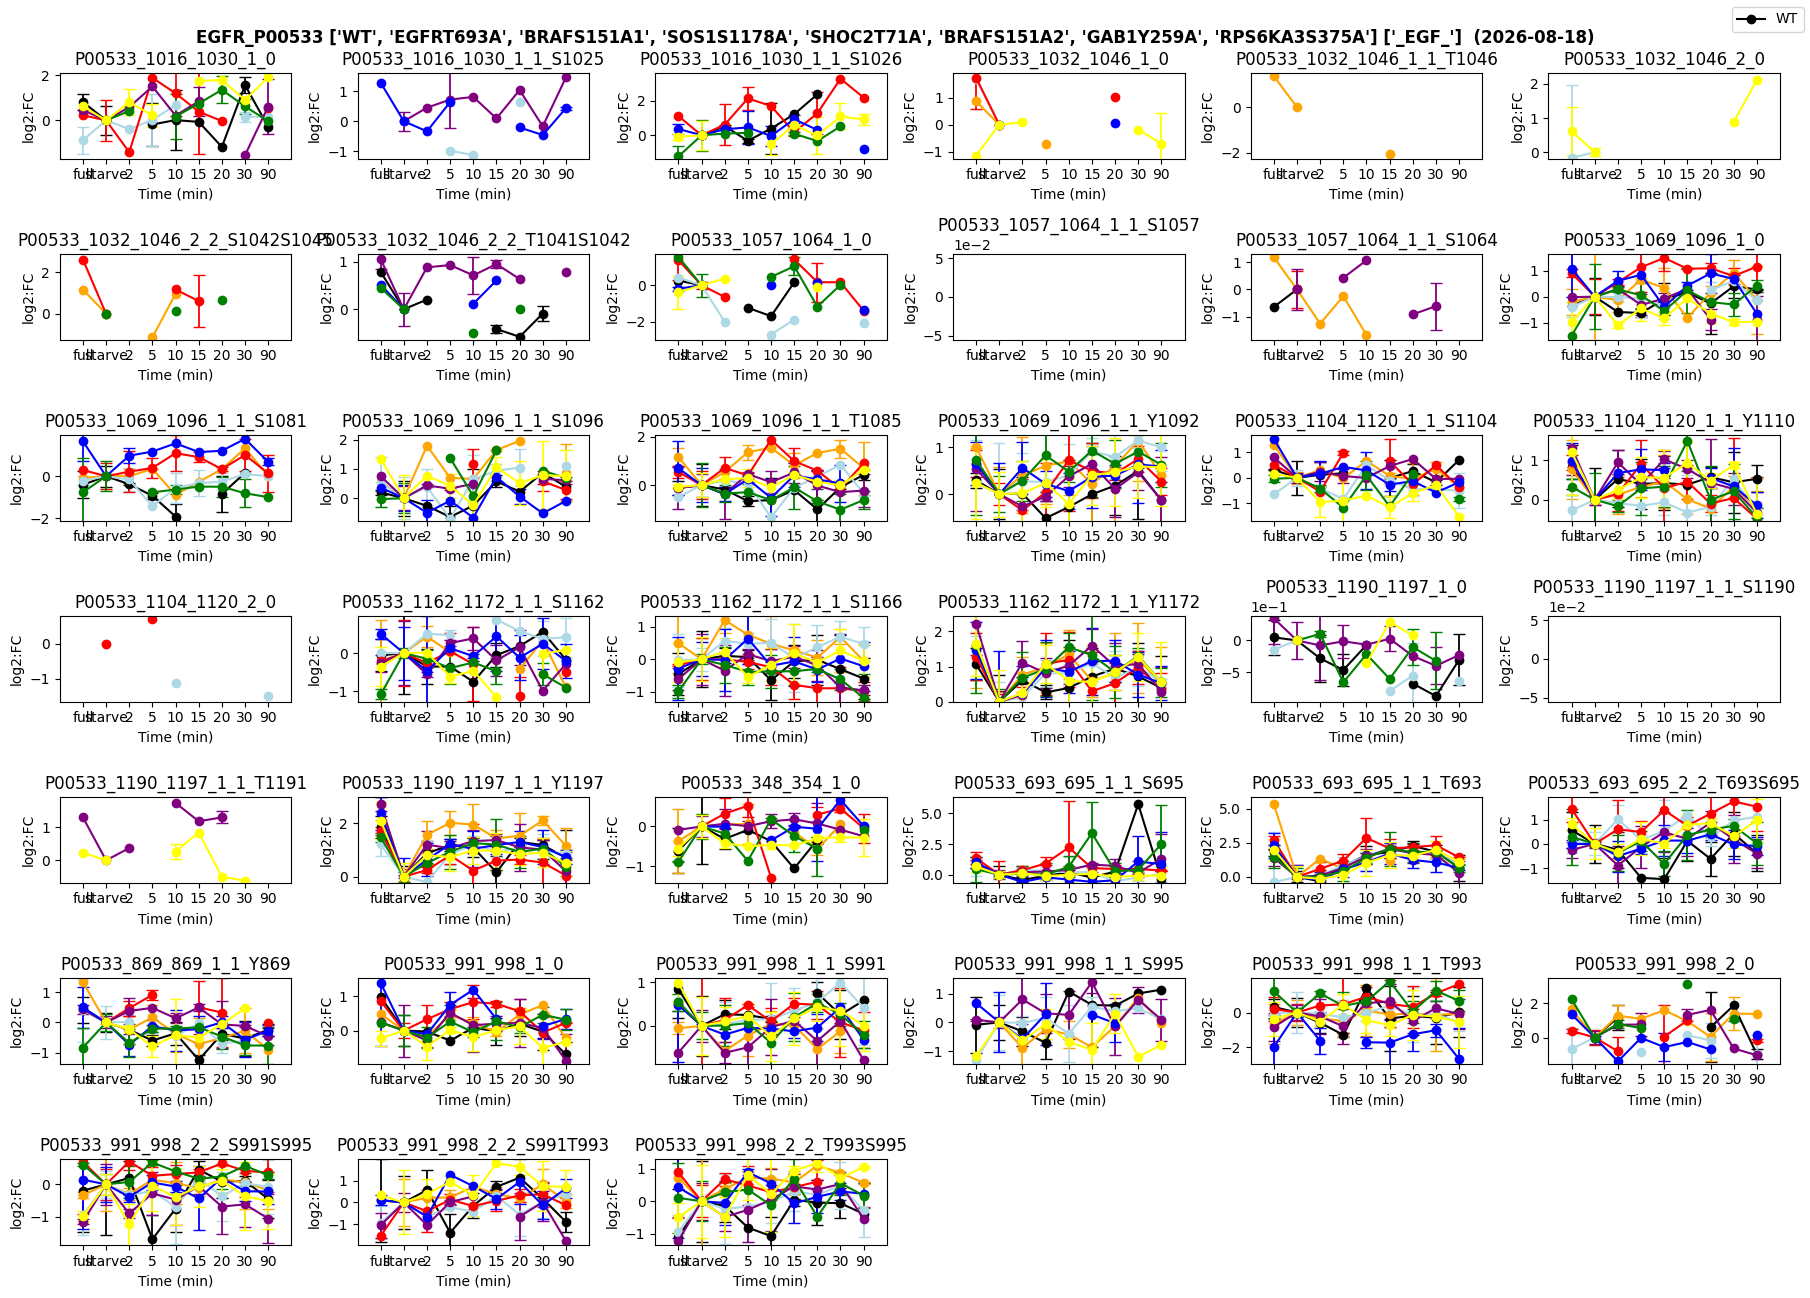

In [104]:
plot_protein_phosphosites(df,
                          data_type="log2:FC",
                          proteins=["EGFR"],
                          cell_lines=CELL_LINES,
                          conditions=['_EGF_'],
                          legend_plot=["WT"],
                          color_palette={"WT" : "black",
                                         "EGFRT693A" : "orange",
                                         "BRAFS151A1" : "lightblue",
                                         "SOS1S1178A" : "red",
                                         "SHOC2T71A" : "purple",
                                         "BRAFS151A2" : "blue",
                                         "GAB1Y259A" : "green",
                                         "RPS6KA3S375A" : "yellow", },
                          saving_path="",
                          saving_info="",
                          title_info="",
                          fit_y_lims= True,
                          one_figure_per_site=False,
                          plot_close=False,
                          save_pdf=False,
                          save_png=False,

                          )